In [7]:
from sklearn.datasets import fetch_california_housing
import torch
import pandas as pd
from torch import optim
import numpy as np

In [8]:
features, target = fetch_california_housing(return_X_y = True, as_frame = True)
features

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, random_state = 42)

In [10]:
y_test.shape

(5160,)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train = np.array(y_train)
y_test = np.array(y_test)


y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1,1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1,1)

In [20]:
X_train_tensor.shape

torch.Size([15480, 8])

In [12]:
y_train_tensor.shape

torch.Size([15480, 1])

In [13]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth = 5)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5)

### Model Creation

In [14]:
import torch.nn as nn

class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        self.network = nn.Sequential(nn.Linear(input_size,hidden_size),
                                    nn.Linear(hidden_size,output_size))
    def forward(self, x):
        return self.network(x)

In [15]:
input_size = 8
hidden_size = 12
output_size = 1

model = SimpleNN(input_size, hidden_size, output_size)

In [16]:
# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
epochs = 1500
for epoch in range(epochs):
    model.train()  # Set the model to training mode

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [10/1500], Loss: 5.7100
Epoch [20/1500], Loss: 5.4557
Epoch [30/1500], Loss: 5.2205
Epoch [40/1500], Loss: 4.9989
Epoch [50/1500], Loss: 4.7869
Epoch [60/1500], Loss: 4.5818
Epoch [70/1500], Loss: 4.3818
Epoch [80/1500], Loss: 4.1855
Epoch [90/1500], Loss: 3.9923
Epoch [100/1500], Loss: 3.8014
Epoch [110/1500], Loss: 3.6127
Epoch [120/1500], Loss: 3.4262
Epoch [130/1500], Loss: 3.2421
Epoch [140/1500], Loss: 3.0607
Epoch [150/1500], Loss: 2.8827
Epoch [160/1500], Loss: 2.7088
Epoch [170/1500], Loss: 2.5395
Epoch [180/1500], Loss: 2.3755
Epoch [190/1500], Loss: 2.2174
Epoch [200/1500], Loss: 2.0656
Epoch [210/1500], Loss: 1.9203
Epoch [220/1500], Loss: 1.7817
Epoch [230/1500], Loss: 1.6500
Epoch [240/1500], Loss: 1.5255
Epoch [250/1500], Loss: 1.4083
Epoch [260/1500], Loss: 1.2988
Epoch [270/1500], Loss: 1.1973
Epoch [280/1500], Loss: 1.1039
Epoch [290/1500], Loss: 1.0188
Epoch [300/1500], Loss: 0.9420
Epoch [310/1500], Loss: 0.8735
Epoch [320/1500], Loss: 0.8131
Epoch [330/1500],

### Model Evaluation

Test Loss: 0.5411


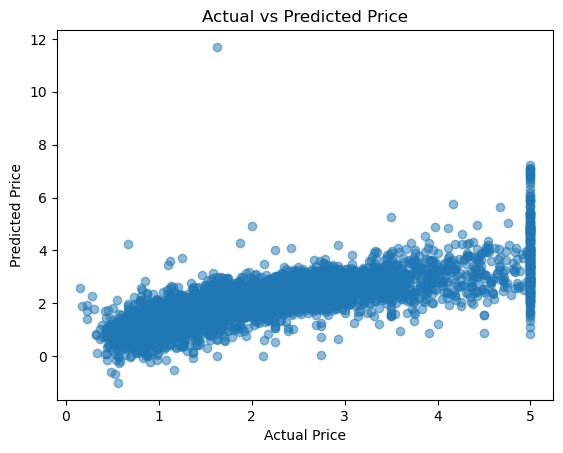

In [17]:
model.eval()  # This sets the model to evaluation mode
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_loss = criterion(predictions, y_test_tensor)
    print(f'Test Loss: {test_loss.item():.4f}')

# Plotting our results
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions.numpy(), alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()


In [21]:
from sklearn.metrics import r2_score

# Evaluate the model
#model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    predictions = model(X_test_tensor).numpy()
    actuals = y_test_tensor.numpy()

r2 = r2_score(actuals, predictions)
print(f'R2 score: {r2:.4f}')

R2 score: 0.5911
